# Script to identify $\beta$-lactam motifs in a dataset of SMILES


### 1- Beta-lactam motif

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
#penicillin (source : https://pubchem.ncbi.nlm.nih.gov/compound/Penicillins#section=Names-and-Identifiers)
inchi = "InChI=1S/C16H18N2O4S/c1-16(2)12(15(21)22)18-13(20)11(14(18)23-16)17-10(19)8-9-6-4-3-5-7-9/h3-7,11-12,14H,8H2,1-2H3,(H,17,19)(H,21,22)"
mol = Chem.MolFromInchi(inchi)
pen_smiles = Chem.MolToSmiles(mol)
print(pen_smiles)

CC1(C)SC2C(N=C(O)Cc3ccccc3)C(=O)N2C1C(=O)O


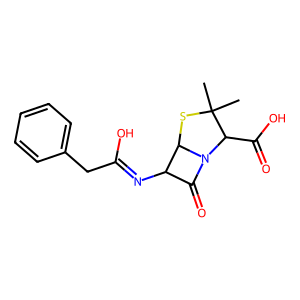

In [2]:
Draw.MolToImage(mol, size=(300, 300))


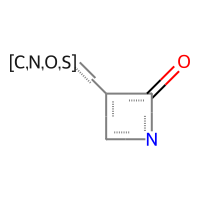

In [3]:
# Visualize beta-lactam motif
#beta_lactam_smarts = '[#6;r4]1[#6;r4][#6;r4](=O)[#7;r4]1'
from rdkit import Chem

beta_lactam_smarts = "[#6;r4]1[#6;r4]([#6,#7,#8,#16])[#6;r4](=O)[#7;r4]1"
query = Chem.MolFromSmarts(beta_lactam_smarts)
Draw.MolToImage(query, size=(200, 200))

In [4]:
#check beta_lactam motif in penicillin

print(mol.HasSubstructMatch(query))

True


### 2-  Prepare Zinc files groups to run on array sbatches

In [27]:
ls ./data/ZINC/ZINC/*.smi | sort > zinc_files.txt

In [35]:
!mkdir -p data/ZINC/zinc_groups
!split -d -n l/10 data/ZINC/zinc_files_names.txt data/ZINC/zinc_groups/group_

In [33]:
ls ./data/ZINC/ZINC/*.smi | sort | xargs -n 1 basename > zinc_files_names.txt


### 3 - Test script on small antibacterial dataset

In [15]:
# load chembl antibacterial compounds 
#(source: Synthemol chembl compounds from 2 search queries antibiotics and antibacterial)
import pandas as pd
df = pd.read_csv('data/chembl_antibacterial.csv')

In [16]:
print(len(df))
print(df.head())

1005
                                              smiles  \
0  Br.C[C@@H](O)[C@H]1C(=O)N2C(C(=O)OCOC(=O)C(C)(...   
1  C#C[C@@]1(O)[C@H](C)O[C@@H](O[C@H]2[C@H](C)[C@...   
2  C#C[C@@]1(O)[C@H](C)O[C@@H](O[C@H]2[C@H](C)[C@...   
3  C/C(=C\C(=O)OCCCCCCCCC(=O)O)C[C@@H]1OC[C@H](C[...   
4  C/C(=C\c1csc(C)n1)[C@@H]1C[C@@H]2O[C@]2(C)CCC[...   

                     labels      ChEMBL ID                            Name  \
0  antibacterial;antibiotic  CHEMBL4297677  TEBIPENEM PIVOXIL HYDROBROMIDE   
1                antibiotic   CHEMBL292174                             NaN   
2                antibiotic   CHEMBL298584                             NaN   
3  antibacterial;antibiotic      CHEMBL719                       MUPIROCIN   
4                antibiotic  CHEMBL1201752                     IXABEPILONE   

                                            Synonyms            Type  \
0  SPR-994|SPR994|TBPM-PI-HBr|TEBIPENEM PIVOXIL H...  Small molecule   
1                                            

In [26]:
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)

def has_substructure_mol(mol, query) -> bool:
    if mol is None:
        return False
    return mol.HasSubstructMatch(query)

df['beta_lactam'] = df['mol'].apply(
    lambda m: has_substructure_mol(m, query)
)

In [28]:
beta_lactams =df[df['beta_lactam']]
print(len(beta_lactams))

200


In [31]:
import pandas as pd
import os
import numpy as np

df = pd.read_csv("chembl_antibacterial.csv")

# create 2 fake ZINC files
os.makedirs("./data/ZINC", exist_ok=True)

for i, chunk in enumerate(np.array_split(df['smiles'], 2)):
    file_path = f"./data/ZINC/fake_zinc_{i+1}.smi"
    chunk.to_csv(file_path, index=False, header=False)

/home/mila/r/rogetc/gflownet/envs/synthemol/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [96]:
ls ./data/ZINC/*.smi | sort | xargs -n 1 basename > ./data/ZINC/fake_zinc_files_names.txt

In [97]:
!mkdir -p data/ZINC/fake_zinc_groups
!split -d -n l/1 data/ZINC/fake_zinc_files_names.txt data/ZINC/fake_zinc_groups/group_

In [13]:
import pandas as pd
import os
import numpy as np

df = pd.read_csv("chembl_antibacterial.csv")
def create_fake_pubchem_file(df, pubchem_file='./data/pubchem/fake_pubchem.smi'):
    import os
    os.makedirs(os.path.dirname(pubchem_file), exist_ok=True)
    pubchem_df = df.copy()
    pubchem_df['CID'] = range(1, len(pubchem_df)+1)  # dummy CIDs
    pubchem_df = pubchem_df[['CID', 'smiles']]
    # write space-separated, no header, no index
    pubchem_df.to_csv(pubchem_file, sep=' ', index=False, header=False)
    print(f"Created fake PubChem file at {pubchem_file}")
create_fake_pubchem_file(df)

Created fake PubChem file at ./data/pubchem/fake_pubchem.smi


In [93]:
%run beta_lactams_screening.py \
    --pubchem_input data/pubchem/fake_pubchem.smi \
    --pubchem_output data/pubchem/test_beta_lactams_fake_pubchem.csv \
    --n_cpus 1
    

PubChem finished: 200/1005 beta-lactams


In [100]:
# Directory to store group files

%run beta_lactams_screening.py \
--zinc_file_list data/ZINC/fake_zinc_groups/group_00 \
--zinc_output data/ZINC/fake_zinc_out/zinc_out_00.csv \
--zinc_base_dir data/ZINC \
--n_cpus 1

data/ZINC/fake_zinc_1.smi: 93/503 beta-lactams found
data/ZINC/fake_zinc_2.smi: 107/502 beta-lactams found


In [39]:
import pandas as pd

df_zinc = pd.read_csv('./test_beta_lactams_zinc.csv')
df_pubchem = pd.read_csv('./test_beta_lactams_pubchem.csv')

print("ZINC hits:", len(df_zinc))
print("PubChem hits:", len(df_pubchem))
df_zinc.head()

ZINC hits: 200
PubChem hits: 200


,SMILES
0,CO/N=C(/C(=O)N[C@@H]1C(=O)N2C(C(=O)OC(C)OC(=O)...
1,CO/N=C(\C(=O)N[C@@H]1C(=O)N(OCC(=O)O)[C@H]1C)c...
2,CO/N=C(\C(=O)N[C@@H]1C(=O)N(OCC(=O)OCC(=O)OC(C...
3,CO/N=C(\C(=O)N[C@@H]1C(=O)N(OCC(=O)[O-])[C@H]1...
4,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(/C=C\c...


### 4-  Import real ZInc15 and pubchem files from MOLFORMER

In [3]:
import requests

url = "https://public.boxcloud.com/d/1/b1!h38Xt3t2xslKA50xNA9vI1i-7kHexRJ-3SOpKtUM0CHUGoZqL53-Q8JmJobAPCL1QbgeQiyyMPKks1QUtpev3QbQDKuWDhKCXO2qTkh8CsOOFD5Ju2wQz7rdTHcTAAlKTxVk-0QlKbNWnrA0GiJ9nQhRAMxUSfPgh0TA0ff1DiiVSLnyQKDo2U3QiOUTEOUFK0PPe_-I4pFmamkANAaWPq0KKAeFDc3r8BpVhSMZU3_32crTdlSwaydivBvG8M2aQWWrFqv4kj1M_9fapuxj1gPz4uEuWSPqY3pnEogIjD0aej02bxw3ZWF7yRyzTb-YV8oO5xS4860crMl-jHIjEk2ve0-RfnGXKv776AHVY3cJ6xg6RtucyRqV_dy3WwhOoyM4ua2WUeMz-kIpsymJ5eyOwDXfdn2HQ4QUujPar6TC1cw9GuZ0979zjN-auNrDB7bwYZQjIefS06w0sSi165oEZBFspJm94KUqjvFf9_w9kfXyeEbxLuzxhIOicXUD4UPfZNIiUPl03n65z9Qdyvpmsgvv5XfbW02BH8VA2MeVUOcxZMe26WQQcrcdHAPs7FPSkDkCNOk8DUlTwSbgPbWUg_uij0-Moc7okMxBBzJr-dIbYbRAAVUJLOPizFkvFEmoslcD4Dh6ifyREdXioL4F9xRf4cyaTe6W3bv8z5wmXdxh88j889tQbl3YwTl-Lf6SBC7ZaNtIKOD8fx8pI3jHkg__70XNniZCqldo91aXAfNmlCb0jcI_NIbmCDbOIs6NT_F8jP0XksUm_YFCTgNgpr0Bxz6Mb2Rig-JLpEkS4oPwaPcJBXFjHADBl4B6FaUHaVnd3r9Ks0dMbZbh08SZ0G6KYBNkZ41cupHS0nEmTPMq_LnP_8XK6Eeu5ZoBVYcqYXIY5ffnnljSuRwlUfgI70PNlFvt4TdTq71BSqXbxBaGz4gv_ScZUclizcpFoxRVGvvRFs9u522Wj5NiwHzl2tKHmaX42ghzJ0nXolwVItc_jDsfGd8dzI9GigVX_7_S_1vm_bTUA7bh51eSZff972ucalGZDyFR2k4raXY11RquTSp0IdgeoWbuZdCrFAvYLTpuZU2ejnd5iy-MEz2cVPTjMMjsEyessYgS4_sUE8TwGV4VJz4YXIIT-Ndrul4LXOT_u6eipZBVZfv_9dv_9MxxLb6EsMAALWDm-ht8KVNakIKNdXk72TIS5LexoTW9Qp1QfPeUkHkvA2oXhSKm3U9ubLhtDqFELoeB0C7ypsAgjoHFSCNEoUGoic27VfBlKW3Wywg8UnAhAkQoOcYdTVCJaJArNmabOg1y71DWNYnNQjP3iXtzr23b68fd-xblboQTxLvnjKSoAPr9zDaaTgpOchIOFd9F-wttPTE8ijLd0i0t5I77VeUmHVCYtjcHymgf-UEYfl29sY0xHzN7bK1NS_SwDyXQkP6u-QU9CvunYA../download"  # zip file URL
output_zip = "./data/pubchem/pubchem_canonical.zip"

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(output_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):  # 1 MB chunks
            if chunk:
                f.write(chunk)

print("Download complete:", output_zip)

Download complete: ./data/pubchem/pubchem_canonical.zip


In [4]:
import zipfile

with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall("./data/pubchem/")  # extracts all files into this folder

print("Extraction complete!")

Extraction complete!


In [8]:
zinc15_url = "https://public.boxcloud.com/d/1/b1!_h169MLAjUCQWEwZQ9SmX8nyOmaZmqQPJKL-BcZjrEti3-ed08Wtcy2tqmSslSrbVCbX6563FFx2r6MvA1bnxQN4y4X6t6wgJwQzuMq0rp5qqS6Z1qSrWkVMama067vj0TDu7wRV9NBvGrpyZXCgavJ9L9viZzMSGFK3DzNgCzU1uCMFeADPanlBxL4LkEVEDEeGE4x3b6JEupFKR_xep0CEwt723lFeBU7yT8YEy4Y8A6bdrf1savgN0zEGeynEtur4NtaxtzsVilFC_-RnCUh0-HO3iPWHwUuAbWkTVlOyZDA7hCqXUDGN-7A9j4QLkADVlf61jFo06y9AWjE8lS32BMjspoCy3m2HCHOWuXcyHuRbO9bgvYq6VDzkIG-Axkq4RZ_dhr5SaQ4TnCaelg5JJUQYvgWAtZfDOICwPTk3TXpYZ3p7SCTDNoLnTE-qAEL3lpeYxQP1sLzVv8ODOM3b2qz0nEDjQN5WW7eQGhmdRUwD2U5bzni67Jof4rL2Z1OqNWYw-GBLVUwvOcLN-h25kva6naKbFR2uDGTi3g4qWu_1yw6kMYyVPEFK3V1RhhckGrsSQzw-N31ZbmSyX6m7aTQMoZmTJWyy_xS-HF04VXl3lKcFCNXQ3TvJgCOaeQKtBS7Qxk7AAvzp2X1xELIA3zuNHhizz9BJuNSxkEtBU_fKaFcyCS5d3c769Cte1BxDOuRy7Dv_Sp9Q_xqfx9HEtbYMwnSXXmTXlFttoK6x8OcI6UdFDld8RrTPKkXOr9AK_kvKpaQyjTwsfP8VvZv3i48caC2m44LjHn8XVs4DaYz1r7Y2zffIXRHDOSc3plQr9mv6WeBgLiiQnn5fPBbtaI_1cVFGfpM-d_3bxOn5j-MGhdFkuoBEDtchtIAq5oozsLAwgslyhCO65aGqukJH1LXUwNNu6N7lavquumc7xyyNc_ENAX-l2A_FgAIivdb-xFSIPmVrChHQUf37dYNDHgd68pHdB-pyqlFNlgpeFPak7Ho1gmZ8YByQUB4rrLdBM-rQMZm3ivWDA364pwCvCJsliwyozW9a_yMjxG1CEJyj-dcjZEY7GTodtMNE5rzpSLVO-T-Hxuil70DpvqMkdWeyEby9Axl_e0AJvxC5wmZMz3MNhqV7P67ln-lhsWw9OAU1idOMH2fcp_00R4v11c1KynEFWkNOo_gwXmTK2_eHBnU04WbuA8KmyhZGTaLQ9Q1EdtjyHH15VxGLp_-uXQ6HTqsJkTpbCXAPozOFRfyZv6o1GCuQ6sGrJeaP-lQudHDGqs3wDZ7Gl715iIqQhNNmMCoSZL5B-e6X85pDmvfMupq7wrUf2xLEOWqVrljD41Y5conVpbNWveiF_mYs3OT75m3LcrATSwfDjfGDhTUVFE40tc6xWjoZH2g7hkfdcAZisoiMTGI./download"
output_zip = "./data/ZINC/ZINC15.zip"

with requests.get(zinc15_url, stream=True) as r:
    r.raise_for_status()
    with open(output_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):  # 1 MB chunks
            if chunk:
                f.write(chunk)

print("Download complete:", output_zip)

Download complete: ./data/ZINC/ZINC15.zip


In [9]:
import zipfile

with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall("./data/ZINC/")  # extracts all files into this folder

print("Extraction complete!")

Extraction complete!


### 5- Visualize results

In [1]:
import pandas as pd
pubchem_input="data/pubchem/beta_lactams_pubchem_newSMARTS.csv"
df = pd.read_csv(pubchem_input)

In [2]:
print(len(df))
print(df.head())

300173
    CID                                            SMILES
0   162                      CC1(C)SC2C(N)C(=O)N2C1C(=O)O
1  1276          CCC1C(=O)N(S(=O)(=O)c2ccc(C)cc2)C1C(=O)O
2  1284            CCCOC(=O)C1=CSC2C(C(C)OC(C)=O)C(=O)N12
3  1883                     CC1=C(C(=O)O)N2C(=O)C(N)C2SC1
4  2171  CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O


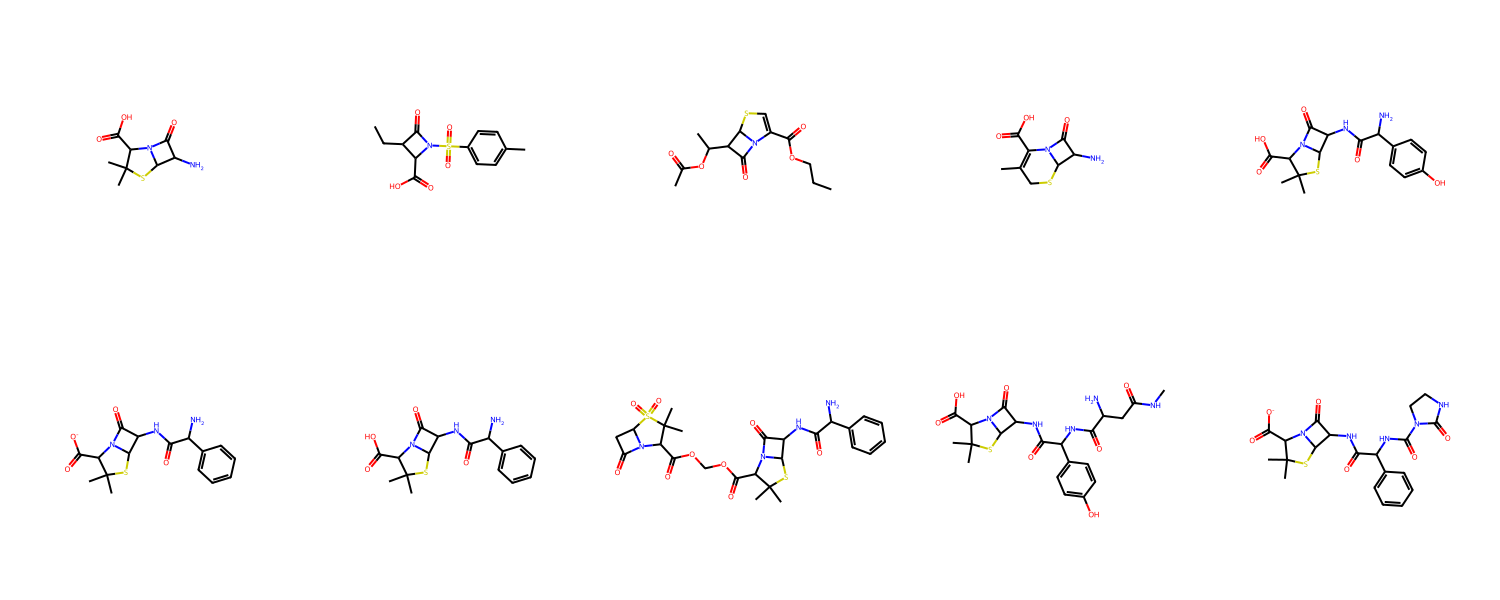

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw


mols = []
for s in df['SMILES'][:10]:
    mol = Chem.MolFromSmiles(s)
    if mol:
        mols.append(mol)

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300,300))


In [10]:
from tqdm import tqdm
tqdm.pandas()

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
    return canonical_smiles

df['canonical_smiles'] = df['SMILES'].progress_apply(canonicalize)

 20%|█▉        | 58553/300173 [00:19<01:32, 2611.39it/s][11:47:55] WARNING: not removing hydrogen atom without neighbors
[11:47:55] WARNING: not removing hydrogen atom without neighbors
 20%|█▉        | 59124/300173 [00:19<01:36, 2492.17it/s][11:47:55] WARNING: not removing hydrogen atom without neighbors
[11:47:55] WARNING: not removing hydrogen atom without neighbors
 21%|██        | 63578/300173 [00:20<01:21, 2907.95it/s][11:47:56] WARNING: not removing hydrogen atom without neighbors
[11:47:56] WARNING: not removing hydrogen atom without neighbors
[11:47:56] WARNING: not removing hydrogen atom without neighbors
 22%|██▏       | 66724/300173 [00:21<01:12, 3198.64it/s][11:47:58] WARNING: not removing hydrogen atom without neighbors
[11:47:58] WARNING: not removing hydrogen atom without neighbors
 32%|███▏      | 96431/300173 [00:31<01:08, 2988.16it/s][11:48:07] WARNING: not removing hydrogen atom without neighbors
[11:48:07] WARNING: not removing hydrogen atom without neighbors
[11:4

In [13]:
df = df.drop_duplicates(subset="canonical_smiles")
print(len(df))

204403


In [22]:
# filter out molecules wit MW <200
from rdkit import Chem
from rdkit.Chem import Descriptors

def compute_mw(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Descriptors.MolWt(mol)

df["mw"] = df["SMILES"].progress_apply(compute_mw)

df_200 = df[df["mw"] >= 200]
print(len(df_200))

 23%|██▎       | 47275/204403 [00:10<00:36, 4270.97it/s][12:56:57] WARNING: not removing hydrogen atom without neighbors
[12:56:57] WARNING: not removing hydrogen atom without neighbors
[12:56:57] WARNING: not removing hydrogen atom without neighbors
 23%|██▎       | 47708/204403 [00:10<00:39, 3959.28it/s][12:56:57] WARNING: not removing hydrogen atom without neighbors
[12:56:57] WARNING: not removing hydrogen atom without neighbors
 25%|██▍       | 50503/204403 [00:10<00:34, 4425.52it/s][12:56:58] WARNING: not removing hydrogen atom without neighbors
[12:56:58] WARNING: not removing hydrogen atom without neighbors
[12:56:58] WARNING: not removing hydrogen atom without neighbors
 37%|███▋      | 74999/204403 [00:16<00:29, 4440.65it/s][12:57:04] WARNING: not removing hydrogen atom without neighbors
[12:57:04] WARNING: not removing hydrogen atom without neighbors
 42%|████▏     | 86264/204403 [00:18<00:22, 5181.42it/s][12:57:06] WARNING: not removing hydrogen atom without neighbors
[12:5

199735


In [14]:
import pandas as pd
import glob

files = sorted(glob.glob('data/ZINC/zinc_out_newSMARTS/zinc_out_*.csv'))

# Read all files and concatenate
dfs = [pd.read_csv(f, sep=' ', header=None, names=['SMILES','CID']) for f in files]
df_all = pd.concat(dfs, ignore_index=True)

# Save with proper header
df_all.to_csv('data/ZINC/zinc_out_newSMARTS/beta_lactams_zinc_all.csv', index=False)

In [15]:
print(len(df_all))
print(df_all.head())

300847
                               SMILES               CID
0    C[C@H]1[C@H](N)C(=O)N1S(=O)(=O)O  ZINC000019851098
1   C[C@@H]1[C@H](N)C(=O)N1S(=O)(=O)O  ZINC000026892291
2                       N[C@H]1CNC1=O  ZINC000039373031
3  C[C@@H]1[C@@H](N)C(=O)N1S(=O)(=O)O  ZINC000056958386
4   C[C@H]1[C@@H](N)C(=O)N1S(=O)(=O)O  ZINC000056958388


In [17]:
import re
from pathlib import Path

# sbatch output files
out_dir = Path("/network/scratch/r/rogetc/beta_lactam/data/sbatch_outputs_newSMARTS")  
pattern = re.compile(r".*:\s*(\d+)/(\d+)\s*beta-lactams found")

total_molecules = 0
total_hits = 0

# loop over all .out files matching your naming pattern
for f in out_dir.glob("beta_lactams_zin15_*.out"):
    with open(f) as fh:
        for line in fh:
            match = pattern.match(line.strip())
            if match:
                hits, n = map(int, match.groups())
                total_hits += hits
                total_molecules += n

print(f"Total ZINC molecules processed: {total_molecules:,}")
print(f"Total beta-lactams found: {total_hits:,}")
print(f"Fraction of beta-lactams: {total_hits/total_molecules:.6f}")

Total ZINC molecules processed: 65,081,397
Total beta-lactams found: 20,975
Fraction of beta-lactams: 0.000322


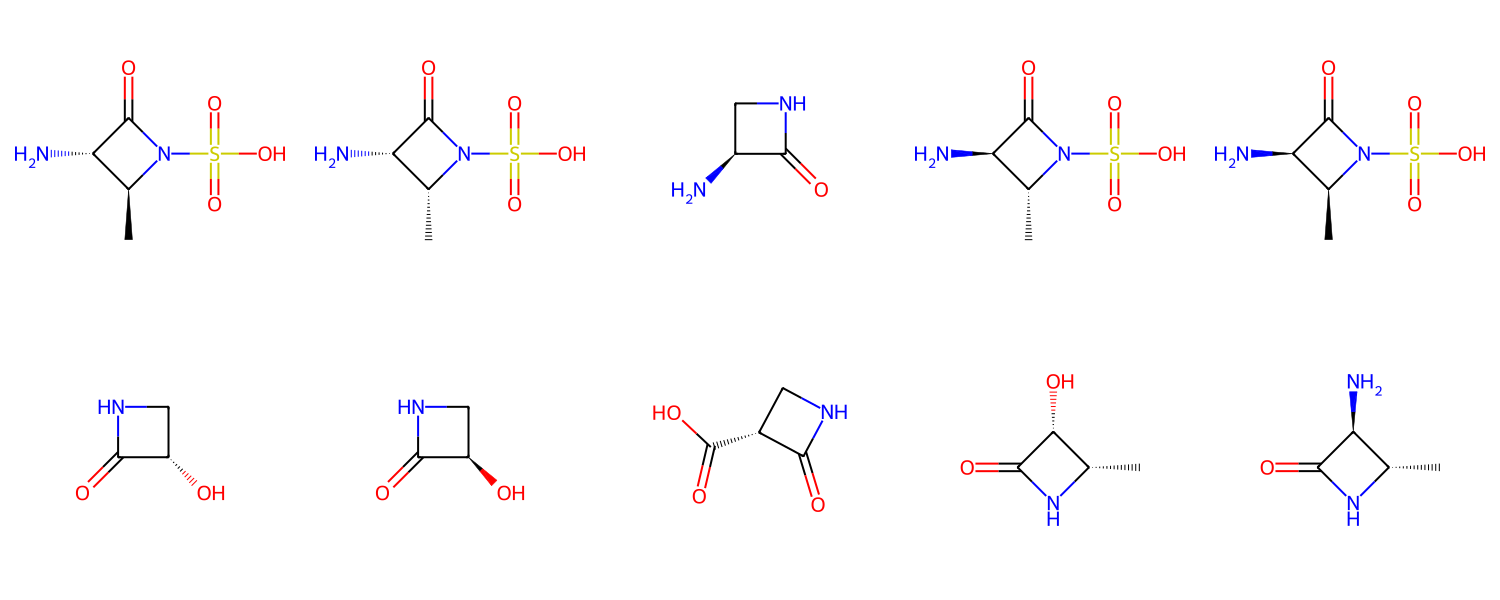

In [18]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = []
for s in df_all['SMILES'][:10]:
    mol = Chem.MolFromSmiles(s)
    if mol:
        mols.append(mol)

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300,300))


In [19]:
#deduplicate SMILES
from rdkit import Chem
from tqdm import tqdm
tqdm.pandas()

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
    return canonical_smiles

df_all['canonical_smiles'] = df_all['SMILES'].progress_apply(canonicalize)


100%|██████████| 300847/300847 [01:24<00:00, 3552.75it/s]


In [20]:
df_all = df_all.drop_duplicates(subset="canonical_smiles")
print(len(df_all))

300845


In [23]:
df_all["mw"] = df_all["SMILES"].progress_apply(compute_mw)

df_all_200 = df_all[df_all["mw"] >= 200]
print(len(df_all_200))

100%|██████████| 300845/300845 [00:54<00:00, 5483.37it/s]

300385


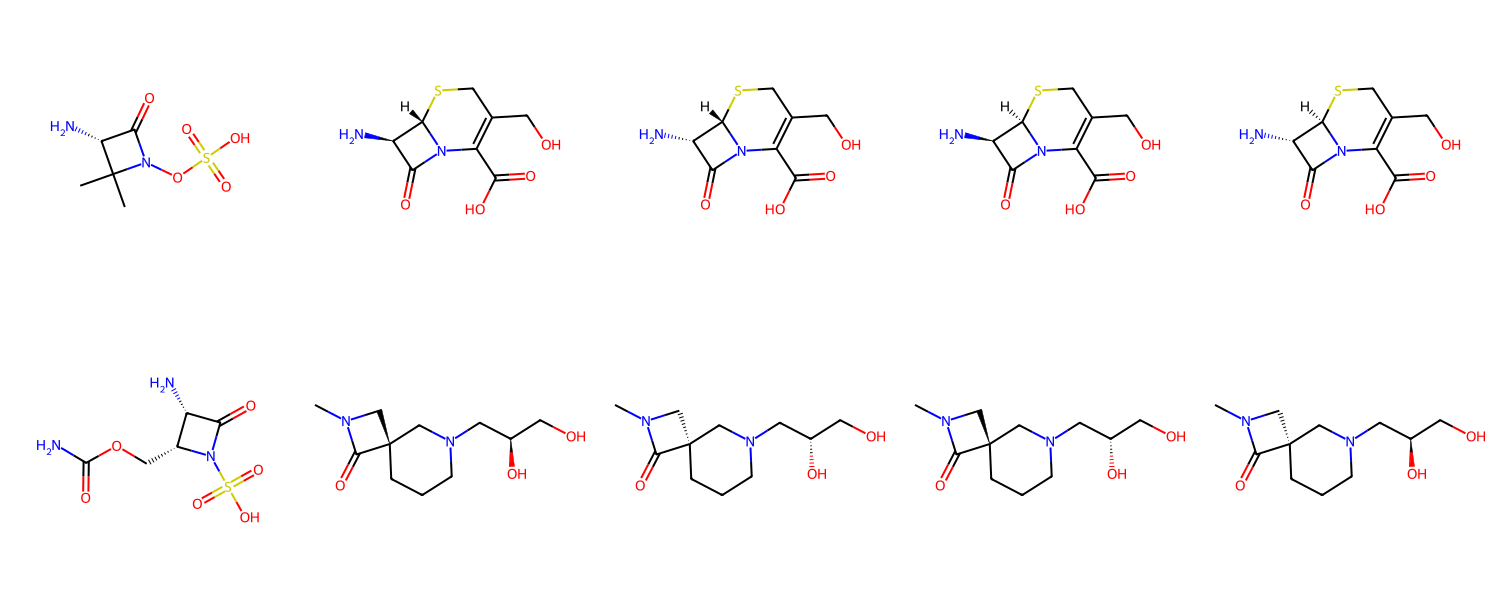

In [24]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = []
for s in df_all_200['SMILES'][:10]:
    mol = Chem.MolFromSmiles(s)
    if mol:
        mols.append(mol)

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300,300))
